# EduPath Career Mapping Evaluation

## UM Career Prospects → O*NET Occupation Mapping

This notebook presents the evaluation conducted to determine how
Universiti Malaya (UM) career-prospect titles can be mapped to
standardized O*NET occupations.

### Purpose of this notebook

The mapping experiment involved multiple datasets, scripts, model
outputs, reviewer files, and intermediate results during development.

This notebook consolidates the experiment into one friendly view so that the methodology, evaluation, results, examples, and final
mapping strategy can be understood without inspecting the entire
development project.

### Important reproducibility note

This notebook **does not call the Gemini API or JobBERT**.

The Gemini and JobBERT outputs used in the experiment were generated
during the data-preparation/evaluation stage and are loaded from the
saved experimental files.

Therefore:

- No Gemini API key is required.
- No API quota is consumed.
- No external model inference is performed.
- Running this notebook reproduces the evaluation and presentation using the saved experiment outputs.

## EduPath: Career Title → O*NET Occupation Mapping


**Purpose:**

Evaluate which mapping approach should be used to convert Universiti Malaya (UM) Career Prospects titles into O*NET
occupations.

**IMPORTANT:**

Gemini is NOT used to recommend careers to students.

Gemini is evaluated only as a one-time data-preparation
method for mapping:

    UM Career Title → O*NET Occupation

The actual EduPath career recommendation is performed
separately using O*NET occupational ratings and cosine
similarity against the student's academic profile.

No Gemini API call is made by this notebook.
All evaluation results are recomputed from saved files.


In [35]:
from google.colab import files
import os
import zipfile
import shutil
from pathlib import Path

#find the file career_mapping/edupath_mapping_evaluation.zip
print("Please upload: edupath_mapping_evaluation.zip")

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No ZIP file was uploaded.")

zip_name = next(iter(uploaded.keys()))

if not zip_name.lower().endswith(".zip"):
    raise ValueError(
        f"Expected a ZIP file, but received: {zip_name}"
    )

# Clean previous extraction
EXTRACT_DIR = Path("/content/edupath_mapping_evaluation")

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(EXTRACT_DIR)

print(f"Uploaded: {zip_name}")
print(f"Extracted to: {EXTRACT_DIR}")

Please upload: edupath_mapping_evaluation.zip


Saving edupath_mapping_evaluation.zip to edupath_mapping_evaluation (2).zip
Uploaded: edupath_mapping_evaluation (2).zip
Extracted to: /content/edupath_mapping_evaluation


### Locate project folder

In [36]:
from pathlib import Path

# Find the folder containing the expected data directory.
possible_roots = [
    EXTRACT_DIR,
    EXTRACT_DIR / "edupath_mapping_evaluation"
]

PROJECT_ROOT = None

for root in possible_roots:
    if (root / "data").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    # Search one level deeper in case the ZIP contains a wrapper folder
    candidates = list(EXTRACT_DIR.rglob("data"))

    if candidates:
        PROJECT_ROOT = candidates[0].parent

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find a 'data' folder inside the uploaded ZIP."
    )

DATA_DIR = PROJECT_ROOT / "data"
MAPPING_EVAL_DIR = DATA_DIR / "mapping_eval"
PRIVATE_DIR = MAPPING_EVAL_DIR / "method_outputs"
print("Project root:")
print(PROJECT_ROOT)

print("\nData directory:")
print(DATA_DIR)

Project root:
/content/edupath_mapping_evaluation

Data directory:
/content/edupath_mapping_evaluation/data


### Verify the important files

## 1. Experiment Files

The notebook uses the saved outputs from the mapping experiment.

The main datasets are:

- UM career prospects
- Evaluation sample
- O*NET occupation titles
- O*NET reported/surveyed titles
- Saved mapping results
- Blind reviewer workbooks
- Saved outputs from the evaluated methods

The notebook does not regenerate these outputs.

In [37]:
required_files = [
    DATA_DIR / "um_career_prospects.csv",
    DATA_DIR / "mapping_eval_sample.csv",
    DATA_DIR / "onet_occupation_titles.csv",
    DATA_DIR / "onet_reported_titles.csv",
    DATA_DIR / "career_title_onet_mapping.csv",
    DATA_DIR / "programme_career_onet_mapping.csv",

    MAPPING_EVAL_DIR / "results_2026-09-18.txt",
    MAPPING_EVAL_DIR / "results_final_2026-09-18.txt",

    MAPPING_EVAL_DIR / "for_reviewers" / "review_Reviewer_A.xlsx",
    MAPPING_EVAL_DIR / "for_reviewers" / "review_Reviewer_B.xlsx",
    MAPPING_EVAL_DIR / "for_reviewers" / "review_Reviewer_C_tiebreak.xlsx",

    PRIVATE_DIR / "method_curated.csv",
    PRIVATE_DIR / "jobbert_top3.csv",
    PRIVATE_DIR / "method_gemini.csv",
    PRIVATE_DIR / "review_PRIVATE_option_key.csv",
]

print("Checking required files...\n")

missing = []

for path in required_files:
    if path.exists():
        print(f"✓ {path.relative_to(PROJECT_ROOT)}")
    else:
        print(f"✗ MISSING: {path.relative_to(PROJECT_ROOT)}")
        missing.append(path)

if missing:
    print("\nWARNING:")
    print("Some files are missing from the uploaded ZIP.")
    print("The notebook may not be able to reproduce all sections.")

else:
    print("\nAll expected files were found.")

Checking required files...

✓ data/um_career_prospects.csv
✓ data/mapping_eval_sample.csv
✓ data/onet_occupation_titles.csv
✓ data/onet_reported_titles.csv
✓ data/career_title_onet_mapping.csv
✓ data/programme_career_onet_mapping.csv
✓ data/mapping_eval/results_2026-09-18.txt
✓ data/mapping_eval/results_final_2026-09-18.txt
✓ data/mapping_eval/for_reviewers/review_Reviewer_A.xlsx
✓ data/mapping_eval/for_reviewers/review_Reviewer_B.xlsx
✓ data/mapping_eval/for_reviewers/review_Reviewer_C_tiebreak.xlsx
✓ data/mapping_eval/method_outputs/method_curated.csv
✓ data/mapping_eval/method_outputs/jobbert_top3.csv
✓ data/mapping_eval/method_outputs/method_gemini.csv
✓ data/mapping_eval/method_outputs/review_PRIVATE_option_key.csv

All expected files were found.


### Load main datasets

## 2. Dataset Overview
The mapping problem begins with UM's programme-specific career
prospects.

These career titles are free-text titles and therefore need to be
linked to standardized O*NET occupations before O*NET occupational
skill and knowledge information can be used for career matching.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import textwrap
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

print("Libraries loaded.")

um_careers = pd.read_csv(DATA_DIR / "um_career_prospects.csv")
eval_sample = pd.read_csv(DATA_DIR / "mapping_eval_sample.csv")
onet_occupations = pd.read_csv(DATA_DIR / "onet_occupation_titles.csv")
onet_reported = pd.read_csv(DATA_DIR / "onet_reported_titles.csv")

print("UM career prospects:", um_careers.shape)
print("Evaluation sample:", eval_sample.shape)
print("O*NET occupations:", onet_occupations.shape)
print("O*NET reported titles:", onet_reported.shape)

print("\nUM career prospect columns:")
print(list(um_careers.columns))

print("\nEvaluation sample columns:")
print(list(eval_sample.columns))

print("\nO*NET occupation columns:")
print(list(onet_occupations.columns))

Libraries loaded.
UM career prospects: (1615, 4)
Evaluation sample: (100, 3)
O*NET occupations: (1016, 2)
O*NET reported titles: (8189, 2)

UM career prospect columns:
['faculty', 'programme', 'programme_slug', 'career_title']

Evaluation sample columns:
['um_title', 'stratum_faculty', 'programmes']

O*NET occupation columns:
['onet_code', 'onet_title']


### Dataset statistics

In [39]:
def find_column(df, candidates):
    """
    Find a column using case-insensitive matching.
    """
    normalized = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for candidate in candidates:
        key = candidate.strip().lower()
        if key in normalized:
            return normalized[key]

    # Partial matching fallback
    for c in df.columns:
        cl = str(c).strip().lower()
        for candidate in candidates:
            if candidate.strip().lower() in cl:
                return c

    return None


programme_col = find_column(
    um_careers,
    ["programme", "program", "programme_name"]
)

faculty_col = find_column(
    um_careers,
    ["faculty", "faculty_name"]
)

career_col = find_column(
    um_careers,
    ["career_title", "career", "career prospect", "title"]
)

print("Detected columns:")
print("Programme:", programme_col)
print("Faculty:", faculty_col)
print("Career title:", career_col)

if programme_col:
    programme_count = um_careers[programme_col].nunique()
else:
    programme_count = "Unavailable"

if faculty_col:
    faculty_count = um_careers[faculty_col].nunique()
else:
    faculty_count = "Unavailable"

if career_col:
    career_count = um_careers[career_col].nunique()
else:
    career_count = "Unavailable"

summary = pd.DataFrame({
    "Metric": [
        "Programmes",
        "Faculties",
        "Career prospect rows",
        "Unique career titles",
        "Evaluation sample"
    ],
    "Value": [
        programme_count,
        faculty_count,
        len(um_careers),
        career_count,
        len(eval_sample)
    ]
})

display(summary)

Detected columns:
Programme: programme
Faculty: faculty
Career title: career_title


,Metric,Value
0,Programmes,80
1,Faculties,17
2,Career prospect rows,1615
3,Unique career titles,1010
4,Evaluation sample,100


### How the career data was collected

Each UM programme page on `study.um.edu.my` has a *Career Prospects* section. The code below is the scraper
used to build `um_career_prospects.csv`. Two practical notes:
- the portal answers requests **without a browser User-Agent with HTTP 500**, so one is always sent;
- requests are spaced 1.5 s apart, since this is a public university website, not an API.

The analysis uses the **frozen scrape of 2026-09-18**. Set `RUN_LIVE_SCRAPE = True` to re-scrape (about 3 minutes)
and compare it with the frozen file. Differences would mean UM has updated its pages since.


In [40]:
import requests
from bs4 import BeautifulSoup
import time

BASE_URL = "https://study.um.edu.my/"
HEADERS = {"User-Agent": "Mozilla/5.0 (FYP research scraper; UM student project)"}   # without one the site returns HTTP 500
NAV_LINKS = {"index", "programmes", "undergraduate-faculties", "international-student",
             "how-to-apply", "faqs-amp-info", "our-team"}

def fetch(slug, delay=1.5):
    for wait in [0, 3, 10, 30]:
        time.sleep(wait)
        try:
            r = requests.get(BASE_URL + slug, headers=HEADERS, timeout=30)
            if r.status_code == 200:
                time.sleep(delay)                      # be polite to a public university site
                return BeautifulSoup(r.text, "html.parser")
        except requests.RequestException:
            pass
    return None

def local_links(soup):
    out = []
    for a in soup.find_all("a", href=True):
        h = a["href"].strip().lstrip("/")
        if h and not h.startswith(("#", "http", "mailto:")) and "." not in h:
            out.append(h)
    return list(dict.fromkeys(out))

def split_careers(text):
    parts = re.split(r"[,;\n•]", text)
    titles = [re.sub(r"^(and|or)\s+", "", re.sub(r"\s+", " ", p).strip(" .\t-"), flags=re.I) for p in parts]
    return list(dict.fromkeys(t for t in titles if t))

def parse_programme(soup):
    h2 = soup.find("h2")
    programme = h2.get_text(" ", strip=True) if h2 else None
    for h4 in soup.find_all("h4"):
        if h4.get_text(strip=True).lower() == "career prospects":
            section = h4.find_next_sibling()
            if section is None:
                return programme, []
            items = [li.get_text(" ", strip=True).strip(" .") for li in section.find_all("li")]
            return programme, (list(dict.fromkeys(i for i in items if i))
                               or split_careers(section.get_text("\n", strip=True)))
    return programme, []

def scrape():
    index = fetch("undergraduate-faculties")
    faculties = [h for h in local_links(index) if h not in NAV_LINKS]
    rows = []
    for fac in faculties:
        fsoup = fetch(fac)
        if fsoup is None:
            continue
        fname = fsoup.find("h2").get_text(" ", strip=True) if fsoup.find("h2") else fac
        for slug in [h for h in local_links(fsoup) if h not in NAV_LINKS and h != fac and h not in faculties]:
            psoup = fetch(slug)
            if psoup is None:
                continue
            programme, careers = parse_programme(psoup)
            rows += [{"faculty": fname, "programme": programme, "programme_slug": slug, "career_title": c}
                     for c in careers]
    return pd.DataFrame(rows)

RUN_LIVE_SCRAPE = False      # the analysis uses the frozen scrape of 2026-09-18; set True to re-scrape (~3 min)
if RUN_LIVE_SCRAPE:
    live = scrape()
    print("live rows:", len(live), "| frozen rows:", len(um_careers), "| identical:",
          set(map(tuple, live.values)) == set(map(tuple, um_careers.values)))
else:
    print("Scraper defined; using the frozen scrape:", len(um_careers), "rows, from",
          um_careers.programme_slug.nunique(), "programmes.")


Scraper defined; using the frozen scrape: 1615 rows, from 80 programmes.


## 3. Why Is Career Mapping Required?

EduPath uses O*NET as a standardized occupational knowledge and skills
source.

However, UM's career-prospect list contains programme-specific
free-text career titles.

For example:

    UM Career Prospect
            ↓
      "Registered Nurse"
            ↓
    O*NET Occupation
            ↓
      "Registered Nurses"
            ↓
    O*NET skill / knowledge profile
            ↓
    Student-to-career similarity

Therefore, the UM career title must first be mapped to an O*NET
occupation.

### Important distinction

Gemini is **not** the final career recommendation engine.

Gemini is used only during data preparation to help map UM career
titles to O*NET occupations.

The actual career recommendation uses the mapped O*NET occupation and
O*NET occupational skill/knowledge information.

## 4. Mapping Methods Evaluated

Three individual mapping approaches were evaluated.

### Method 1 — Curated O*NET title matching

A deterministic matching approach using curated O*NET occupation and
surveyed/reported job titles.

Advantages:

- deterministic
- reproducible
- no API cost
- fast

Limitation:

- only covers titles that can be matched through the available
  O*NET title information

---

### Method 2 — JobBERT

JobBERT was used as a semantic embedding approach.

The UM career title and O*NET occupation titles were compared using
semantic similarity.

Advantages:

- can handle titles that are not exact lexical matches
- provides broad coverage

Limitation:

- semantic similarity does not necessarily mean occupational
  equivalence

---

### Method 3 — Gemini

Gemini was used to map UM career titles to O*NET occupations.

Advantages:

- can interpret context and occupational meaning
- can handle titles that do not have direct lexical matches

Limitation:

- requires API access during data preparation
- consumes API quota
- model output is not deterministic in the same way as curated
  matching

## 5. Final Candidate Strategy

The main hybrid strategy evaluated was:

### Curated → Gemini

    UM Career Title
           ↓
    Curated O*NET match?
       ↙          ↘
    YES           NO
      ↓             ↓
    Use curated   Gemini
    mapping       mapping

This allows deterministic mappings to be used first while Gemini is
reserved for titles that require additional interpretation.

The notebook uses the saved outputs generated during the experiment.
It does not call Gemini again.

## 6. Blind Evaluation

A stratified sample of 100 unique UM career titles was selected before
inspecting the outputs of the evaluated methods.

The sample covers all 17 faculties, with at least three titles per
faculty and the remaining titles allocated proportionally.

For each title, reviewers were shown candidate O*NET occupations.

The candidate options were shuffled and the reviewers did not know
which option was produced by which mapping method.

### Reviewers

- **Reviewer B (independent)** — primary independent reviewer
- **Reviewer A (developer)** — developer/reviewer
- **Reviewer C (tie-break)** — used for disputed titles

Reviewer A did not know which candidate option corresponded to which
mapping method during the blind review.

### Agreement

Reviewer A and Reviewer B agreed on:

**72 / 100 titles**

The remaining 28 disputed titles were reviewed by Reviewer C.

The resulting majority decision provides a second evaluation reference
for 99 titles.

In [41]:
import random
from collections import defaultdict

SEED, SAMPLE_SIZE, MIN_PER_FACULTY = 20260918, 100, 3

def allocate(counts, total, minimum):
    alloc = {f: min(minimum, n) for f, n in counts.items()}
    spare = {f: n - alloc[f] for f, n in counts.items()}
    quotas = {f: (total - sum(alloc.values())) * s / sum(spare.values()) for f, s in spare.items()}
    for f, q in quotas.items():
        alloc[f] += int(q)
    for f in sorted(quotas, key=lambda f: quotas[f] - int(quotas[f]), reverse=True)[:total - sum(alloc.values())]:
        alloc[f] += 1
    return alloc

faculties_of = um_careers.groupby("career_title").faculty.apply(set)
titles_by_faculty = defaultdict(list)
for title, faculties in faculties_of.items():
    titles_by_faculty[sorted(faculties)[0]].append(title)     # a title is counted under one faculty only

alloc = allocate({f: len(t) for f, t in titles_by_faculty.items()}, SAMPLE_SIZE, MIN_PER_FACULTY)
rng = random.Random(SEED)
redrawn = [t for f in sorted(titles_by_faculty) for t in rng.sample(sorted(titles_by_faculty[f]), alloc[f])]

print("Re-drawn sample identical to the saved evaluation sample:", redrawn == list(eval_sample.um_title))
display(pd.Series(alloc, name="titles sampled").sort_values(ascending=False).to_frame())


Re-drawn sample identical to the saved evaluation sample: True


,titles sampled
FACULTY OF ARTS & SOCIAL SCIENCE,10
ACADEMY OF ISLAMIC STUDIES,9
FACULTY OF SCIENCE,8
FACULTY OF ENGINEERING,8
FACULTY OF BUILT ENVIRONMENT,7
FACULTY OF COMPUTER SCIENCE,6
ACADEMY OF MALAY STUDIES,6
FACULTY OF BUSINESS AND ECONOMIC,6
FACULTY OF CREATIVE ARTS,6
FACULTY OF MEDICINE,5


### Load reviewer workbooks

In [42]:
review_dir = MAPPING_EVAL_DIR / "for_reviewers"

review_files = {
    "Reviewer A (developer)": review_dir / "review_Reviewer_A.xlsx",
    "Reviewer B (independent)": review_dir / "review_Reviewer_B.xlsx",
    "Reviewer C (tie-break)": review_dir / "review_Reviewer_C_tiebreak.xlsx",
}

reviewers = {}

for reviewer_name, path in review_files.items():
        reviewers[reviewer_name] = pd.read_excel(path,sheet_name="Review")

        print(f"{reviewer_name}: {len(reviewers[reviewer_name])} titles")

Reviewer A (developer): 100 titles
Reviewer B (independent): 100 titles
Reviewer C (tie-break): 28 titles


### Show one reviewer workbook

In [43]:
print("Preview of Reviewer B (independent):")
display(reviewers["Reviewer B (independent)"].dropna(axis=1, how="all").head(10))

Preview of Reviewer B (independent):


,No,UM career title,Offered in programme(s),Option A,Option B,Option C,Option D,YOUR ANSWER
0,1,Writer Or Author On Islamic Topics,BACHELOR OF ISLAMIC STUDIES AND SCIENCE,"News Analysts, Reporters, and Journalists [27-3023.00]","Poets, Lyricists and Creative Writers [27-3043.05]",Writers and Authors [27-3043.00],NaN,C
1,2,Islamic Education Curriculum Developer,BACHELOR OF ISLAMIC STUDIES AND SCIENCE; BACHELOR OF USULUDDIN,"Education Administrators, Kindergarten through Secondary [11-9032.00]",Instructional Coordinators [25-9031.00],"Directors, Religious Activities and Education [21-2021.00]",NaN,B
2,3,Translator Of Islamic Texts,BACHELOR OF AL-QURAN AND AL-HADITH; BACHELOR OF ISLAMIC STUDIES AND SCIENCE,Interpreters and Translators [27-3091.00],Historians [19-3093.00],Tour Guides and Escorts [39-7011.00],NaN,A
3,4,Financial Planner (Islamic Finance),BACHELOR OF MUAMALAT MANAGEMENT,Personal Financial Advisors [13-2052.00],Financial Managers [11-3031.00],"Securities, Commodities, and Financial Services Sales Agents [41-3031.00]",NaN,A
4,5,Mediator In Islamic Disputes,BACHELOR OF SHARIAH AND LAW,"Claims Adjusters, Examiners, and Investigators [13-1031.00]","Arbitrators, Mediators, and Conciliators [23-1022.00]","Administrative Law Judges, Adjudicators, and Hearing Officers [23-1021.00]",NaN,B
5,6,Compliance Officer In Islamic Banking,BACHELOR OF SHARIAH AND LAW,Financial Examiners [13-2061.00],Compliance Officers [13-1041.00],Compliance Managers [11-9199.02],NaN,B
6,7,Media And Communications Specialist In Islamic Content,BACHELOR OF ISLAMIC STUDIES AND SCIENCE,Public Relations Specialists [27-3031.00],"Media and Communication Workers, All Other [27-3099.00]","Switchboard Operators, Including Answering Service [43-2011.00]",NaN,A
7,8,Islamic Museum Curator,BACHELOR OF ISLAMIC STUDIES AND SCIENCE,Tour Guides and Escorts [39-7011.00],Historians [19-3093.00],Curators [25-4012.00],NaN,C
8,9,Islamic Event Organizer,BACHELOR OF SHARIAH,"Meeting, Convention, and Event Planners [13-1121.00]","Directors, Religious Activities and Education [21-2021.00]",Clergy [21-2011.00],NaN,A
9,10,Tourism Officer,BACHELOR OF ARABIC LANGUAGE AND LINGUISTICS; BACHELOR OF CHINESE LANGUAGE AND LINGUISTICS; BACHELOR OF FRENCH LANGUA...,Fish and Game Wardens [33-3031.00],"Business Operations Specialists, All Other [13-1199.00]",Travel Guides [39-7012.00],Travel Agents [41-3041.00],C


### Reviewer agreement

In [44]:
import re, json

option_key = pd.read_csv(PRIVATE_DIR / "review_PRIVATE_option_key.csv")
options = {row.no: json.loads(row.options) for row in option_key.itertuples()}   # letter -> O*NET code
title_of = dict(zip(option_key.no, option_key.um_title))

def decode(df):
    # Turn each reviewer's letter answer ("B", or "A,C") into a set of O*NET codes.
    labels = {}
    for _, row in df.iterrows():
        answer = str(row["YOUR ANSWER"]).upper() if pd.notna(row["YOUR ANSWER"]) else ""
        if answer == "NONE":
            labels[row["No"]] = {"NONE"}
        elif answer.startswith("OTHER"):
            labels[row["No"]] = {str(row["If OTHER: O*NET code"]).strip()}
        else:
            labels[row["No"]] = {options[row["No"]][l] for l in re.findall(r"[A-H]", answer)}
    return labels

A = decode(reviewers["Reviewer A (developer)"])
B = decode(reviewers["Reviewer B (independent)"])
C = decode(reviewers["Reviewer C (tie-break)"])

agree_AB = {n for n in A if A[n] & B[n]}
double_A = {n for n in A if len(A[n]) > 1}
majority, tiebreak = {}, {"C sided with A": 0, "C sided with B": 0, "No consensus": 0}
for n in A:
    if n in agree_AB:
        majority[n] = A[n] & B[n]
    elif C.get(n, set()) & A[n]:
        majority[n] = C[n] & A[n]; tiebreak["C sided with A"] += 1
    elif C.get(n, set()) & B[n]:
        majority[n] = C[n] & B[n]; tiebreak["C sided with B"] += 1
    else:
        tiebreak["No consensus"] += 1

agreement_summary = pd.DataFrame({
    "Evaluation item": ["Total evaluation titles", "Reviewer A vs Reviewer B agreement",
                        "Disputed titles", "C sided with B", "C sided with A", "No consensus",
                        "Majority decisions available"],
    "Result": [len(A), f"{len(agree_AB)} / {len(A)} ({len(agree_AB)/len(A):.0%})", len(A) - len(agree_AB),
               tiebreak["C sided with B"], tiebreak["C sided with A"], tiebreak["No consensus"], len(majority)],
})
display(agreement_summary)

,Evaluation item,Result
0,Total evaluation titles,100
1,Reviewer A vs Reviewer B agreement,72 / 100 (72%)
2,Disputed titles,28
3,C sided with B,23
4,C sided with A,4
5,No consensus,1
6,Majority decisions available,99


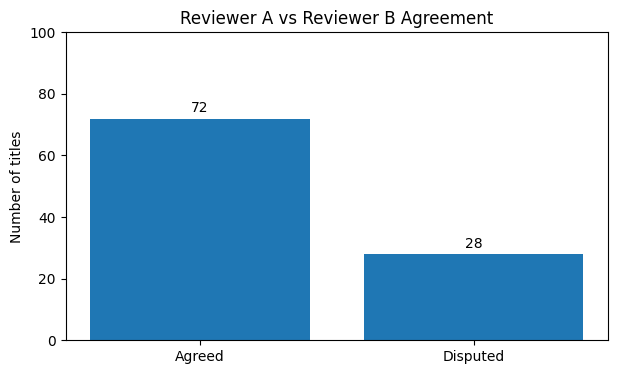

In [45]:
plt.figure(figsize=(7, 4))

labels = ["Agreed", "Disputed"]
values = [len(agree_AB), len(A) - len(agree_AB)]

bars = plt.bar(labels, values)

plt.title("Reviewer A vs Reviewer B Agreement")
plt.ylabel("Number of titles")
plt.ylim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        str(value),
        ha="center"
    )

plt.show()

### Load saved evaluation results

In [46]:
results_file = MAPPING_EVAL_DIR / "results_final_2026-09-18.txt"

if results_file.exists():
    results_text = results_file.read_text(
        encoding="utf-8",
        errors="replace"
    )

    print(results_text)
else:
    print("Final results file not found.")

Reviewer agreement A(developer) vs B(independent): 72/100
Tie-break on 28 disputed titles -> C sided with A: 4 | with B: 23 | neither (no consensus): 1

### PRIMARY: independent Reviewer B  (n=100)
Rule                          Mapped  Correct  Precision  Coverage
R1 Curated only                   27       27       100%       27%
R2 JobBERT only                  100       59        59%      100%
R3 Gemini only                   100       90        90%      100%
R4 Curated>Gemini                100       93        93%      100%
R5 Curated>agree>Gemini          100       93        93%      100%
R6 Curated>agree>unmapped         57       56        98%       57%

### MAJORITY KEY (2 of 3 reviewers)  (n=99)
Rule                          Mapped  Correct  Precision  Coverage
R1 Curated only                   26       25        96%       26%
R2 JobBERT only                   99       55        56%      100%
R3 Gemini only                    99       92        93%      100%
R4 Curated>Gemini   

In [47]:
curated = pd.read_csv(PRIVATE_DIR / "method_curated.csv")
jobbert = pd.read_csv(PRIVATE_DIR / "jobbert_top3.csv")
gemini = pd.read_csv(PRIVATE_DIR / "method_gemini.csv")

curated_map = {t: (None if c == "NONE" else c) for t, c in zip(curated.um_title, curated.onet_code)}
jobbert_map = jobbert[jobbert["rank"] == 1].set_index("um_title").onet_code.to_dict()
gemini_map = {t: (None if c == "NONE" else c) for t, c in zip(gemini.um_title, gemini.onet_code)}

def apply_rules(t):
    c, j, g = curated_map[t], jobbert_map[t], gemini_map[t]
    agree = g if g and g == j else None
    return {"R1 Curated only": c, "R2 JobBERT only": j, "R3 Gemini only": g,
            "R4 Curated → Gemini": c or g, "R5 Curated → agree → Gemini": c or agree or g,
            "R6 Curated → agree → Unmapped": c or agree}

RULES = list(apply_rules(title_of[1]))

def evaluate(reference, titles):
    # Correct = method's occupation is the reviewer's answer, or both say NONE.
    rows = []
    for rule in RULES:
        mapped = correct = 0
        for n in titles:
            out = apply_rules(title_of[n])[rule]
            if out:
                mapped += 1
                correct += out in reference[n]
            elif "NONE" in reference[n]:
                correct += 1
        rows.append({"Rule": rule, "Precision (%)": round(100 * correct / mapped),
                     "Coverage (%)": round(100 * mapped / len(titles))})
    return pd.DataFrame(rows).set_index("Rule")

res_B = evaluate(B, sorted(B))
res_majority = evaluate(majority, sorted(majority))
results = pd.concat({"Reviewer B (independent, n=100)": res_B,
                     f"2-of-3 majority (n={len(majority)})": res_majority}, axis=1)
display(results)

Reviewer B (independent, n=100)               \
                                                Precision (%) Coverage (%)   
Rule                                                                         
R1 Curated only                                           100           27   
R2 JobBERT only                                            59          100   
R3 Gemini only                                             90          100   
R4 Curated → Gemini                                        93          100   
R5 Curated → agree → Gemini                                93          100   
R6 Curated → agree → Unmapped                              98           57   

                              2-of-3 majority (n=99)               
                                       Precision (%) Coverage (%)  
Rule                                                               
R1 Curated only                                   96           26  
R2 JobBERT only                                   56          100  
R3 Gemini only                                    93          100  
R4 Curated → Gemini                               93          100  
R5 Curated → agree → Gemini                       93          100  
R6 Curated → agree → Unmapped                     95           57

### Visualize evaluation results

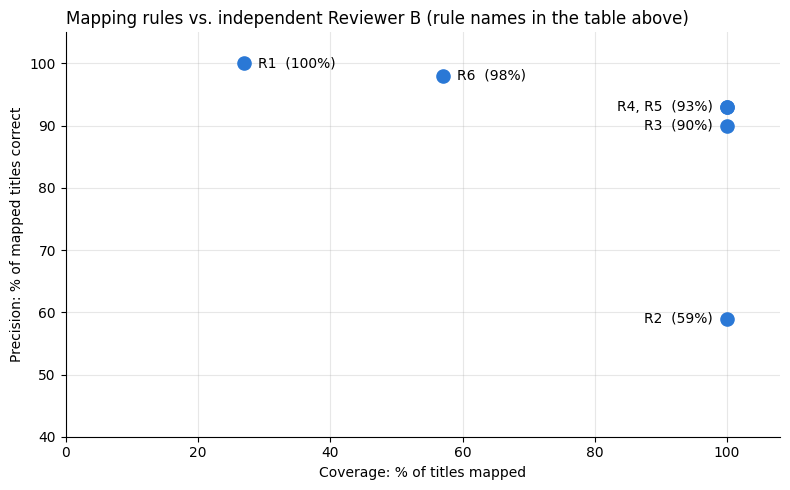

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(res_B["Coverage (%)"], res_B["Precision (%)"], s=90, color="#2a78d6", zorder=3)

# Rules on the identical point (R4 and R5) share one label
points = {}
for rule, r in res_B.iterrows():
    points.setdefault((r["Coverage (%)"], r["Precision (%)"]), []).append(rule.split()[0])
for (x, y), ids in points.items():
    right = x > 80
    ax.annotate(f"{', '.join(ids)}  ({y}%)", (x, y), xytext=(-10 if right else 10, 0),
                textcoords="offset points", va="center", ha="right" if right else "left")

ax.set_xlim(0, 108); ax.set_ylim(40, 105)
ax.set_xlabel("Coverage: % of titles mapped")
ax.set_ylabel("Precision: % of mapped titles correct")
ax.set_title("Mapping rules vs. independent Reviewer B (rule names in the table above)", loc="left")
ax.grid(alpha=0.3)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Interpretation of Evaluation Results

The evaluation shows a clear difference between coverage and mapping
precision across the tested approaches.

**Curated only**

The curated method achieved very high precision on titles it could
match, but its coverage was limited because many UM career titles did
not have a direct curated match.

**JobBERT only**

JobBERT provided 100% coverage but achieved lower precision than the
other full-coverage approaches in this evaluation.

**Gemini only**

Gemini achieved 100% coverage and 93% precision against the 2-of-3
majority evaluation.

**Curated → Gemini**

The hybrid strategy achieved:

- 93% precision against Reviewer B
- 93% precision against the 2-of-3 majority
- 100% coverage

It also uses deterministic curated matching before applying Gemini to
the remaining titles.

Therefore, the selected mapping strategy is:

# Curated → Gemini

## 8. Why JobBERT Was Not Used as the Primary Mapping Method

JobBERT was evaluated as a semantic matching alternative.

Its evaluation results were:

- Reviewer B: 59%
- 2-of-3 majority: 56%
- Coverage: 100%

Although JobBERT provided complete coverage, its evaluated precision
was substantially lower than the Gemini-based full-coverage approaches.

Therefore, JobBERT was not selected as the primary mapping method for
the final pipeline.

## 9. Selected Strategy: Curated → Gemini

The selected strategy combines deterministic matching with LLM-based
fallback mapping.

### Step 1 — Curated matching

Use existing O*NET occupation and reported/surveyed title information
to identify straightforward mappings.

### Step 2 — Gemini fallback

Titles that are not resolved through curated matching are sent to
Gemini during the data-preparation stage.

### Benefits

- deterministic matching is used where possible
- Gemini is reserved for unresolved titles
- 100% evaluation coverage
- 93% evaluated precision against Reviewer B
- 93% evaluated precision against the 2-of-3 majority
- fewer Gemini calls than sending every title directly to Gemini

The Gemini API is therefore a **data-preparation tool**, not the
runtime career recommendation engine.

### Show real examples

In [49]:
occ_title = dict(zip(onet_occupations.onet_code, onet_occupations.onet_title))

def show(code, reference):
    if not code:
        return "—"
    return ("✓ " if code in reference else "✗ ") + occ_title.get(code, code)

examples = pd.DataFrame([{
    "UM title": title_of[n],
    "Reviewers' answer": " / ".join(occ_title[c] for c in majority[n]),
    "Curated": show(curated_map[title_of[n]], majority[n]),
    "JobBERT": show(jobbert_map[title_of[n]], majority[n]),
    "Gemini": show(gemini_map[title_of[n]], majority[n]),
} for n in sorted(majority)])

print("All three methods correct:")
display(examples[examples.Curated.str.startswith("✓") & examples.JobBERT.str.startswith("✓")
                 & examples.Gemini.str.startswith("✓")].head(4))

print("\nJobBERT wrong, Gemini right (why JobBERT was rejected):")
display(examples[examples.JobBERT.str.startswith("✗") & examples.Gemini.str.startswith("✓")].head(6))

print("\nGemini wrong (note Environmental Policy Analyst: curated was right, so R4 puts curated first):")
display(examples[examples.Gemini.str.startswith("✗")])

All three methods correct:


,UM title,Reviewers' answer,Curated,JobBERT,Gemini
3,Financial Planner (Islamic Finance),Personal Financial Advisors,✓ Personal Financial Advisors,✓ Personal Financial Advisors,✓ Personal Financial Advisors
11,Poet,"Poets, Lyricists and Creative Writers","✓ Poets, Lyricists and Creative Writers","✓ Poets, Lyricists and Creative Writers","✓ Poets, Lyricists and Creative Writers"
12,Historian,Historians,✓ Historians,✓ Historians,✓ Historians
13,Proofreader,Proofreaders and Copy Markers,✓ Proofreaders and Copy Markers,✓ Proofreaders and Copy Markers,✓ Proofreaders and Copy Markers



JobBERT wrong, Gemini right (why JobBERT was rejected):


,UM title,Reviewers' answer,Curated,JobBERT,Gemini
0,Writer Or Author On Islamic Topics,Writers and Authors,—,"✗ Poets, Lyricists and Creative Writers",✓ Writers and Authors
8,Islamic Event Organizer,"Meeting, Convention, and Event Planners",—,✗ Clergy,"✓ Meeting, Convention, and Event Planners"
10,Text Analyst,Data Scientists,—,✗ Writers and Authors,✓ Data Scientists
15,Project Coordinator,Project Management Specialists,—,✗ Architectural and Engineering Managers,✓ Project Management Specialists
16,Construction Economist,Cost Estimators,—,✗ Economists,✓ Cost Estimators
21,Estate Planner,Personal Financial Advisors,—,✗ Urban and Regional Planners,✓ Personal Financial Advisors



Gemini wrong (note Environmental Policy Analyst: curated was right, so R4 puts curated first):


,UM title,Reviewers' answer,Curated,JobBERT,Gemini
6,Media And Communications Specialist In Islamic Content,"Media and Communication Workers, All Other",—,✗ Public Relations Specialists,✗ Public Relations Specialists
9,Tourism Officer,Travel Guides,—,✗ Travel Agents,"✗ Business Operations Specialists, All Other"
25,Environmental Policy Analyst,Climate Change Policy Analysts,✓ Climate Change Policy Analysts,✓ Climate Change Policy Analysts,"✗ Environmental Scientists and Specialists, Including Health"
53,Community Dentist,"Dentists, General",—,"✓ Dentists, General","✗ Dentists, All Other Specialists"
56,Psychological Tester,Clinical and Counseling Psychologists,—,✗ Statisticians,"✗ Psychologists, All Other"
69,Religious Educator,"Philosophy and Religion Teachers, Postsecondary",—,"✗ Directors, Religious Activities and Education","✗ Directors, Religious Activities and Education"
77,Public Health Specialist,Preventive Medicine Physicians,—,✓ Preventive Medicine Physicians,✗ Health Education Specialists


## 10. Gemini Confidence Analysis

Gemini confidence was also examined as part of the evaluation.

The results showed that very high confidence was generally associated
with higher correctness, while lower-confidence mappings were less
reliable.

However, applying a 0.90 confidence threshold would discard a
substantial portion of mappings while correcting only a small number
of incorrect mappings.

Therefore, a 0.90 confidence threshold was not adopted as the primary
mapping rule.

In [50]:
# Display confidence-related columns if available

gemini_conf = gemini.set_index("um_title").confidence
confidence = pd.DataFrame([{"confidence": float(gemini_conf[title_of[n]]),
                            "correct": gemini_map[title_of[n]] in majority[n]} for n in majority])

bands = pd.cut(confidence.confidence, [0, 0.85, 0.90, 0.95, 1.0001], right=False,
               labels=["< 0.85", "0.85–0.90", "0.90–0.95", "≥ 0.95"])

display(confidence.groupby(bands, observed=True).correct
        .agg(titles="size", correct_pct=lambda s: round(100 * s.mean())))

below = confidence[confidence.confidence < 0.90]

print(f"A 0.90 threshold would discard {len(below)} of {len(confidence)} titles "
      f"({len(below)/len(confidence):.0%}) to remove {int((~below.correct).sum())} wrong mappings.")

,titles,correct_pct
confidence,,
< 0.85,6,83
0.85–0.90,23,78
0.90–0.95,26,96
≥ 0.95,44,100


A 0.90 threshold would discard 29 of 99 titles (29%) to remove 6 wrong mappings.


## 11. Sensitivity Checks

Additional checks were conducted to determine whether the overall
conclusion depended strongly on a small number of potentially exposed
or ambiguous reviewer decisions.

### Check 1 — Excluding 4 titles whose outputs had previously been seen

The relative conclusion remained unchanged.

### Check 2 — Excluding Reviewer A's 9 double answers

The relative conclusion remained unchanged.

Therefore, the selection of the hybrid strategy was not dependent on
these specific sensitivity conditions.

In [51]:
EXPOSED = {"Registered Nurse", "Nurse Educator", "Forensic Medical Officer", "Mediator In Islamic Disputes"}
exposed = {n for n in title_of if title_of[n] in EXPOSED}

sensitivity = pd.concat({
    f"Majority key (n={len(majority)})": res_majority["Precision (%)"],
    "Excl. 4 titles seen before": evaluate(majority, sorted(set(majority) - exposed))["Precision (%)"],
    "Excl. A's 9 double answers": evaluate(majority, sorted(set(majority) - double_A))["Precision (%)"],
    "vs Reviewer A (developer)": evaluate(A, sorted(A))["Precision (%)"],
}, axis=1)
display(sensitivity)

,Majority key (n=99),Excl. 4 titles seen before,Excl. A's 9 double answers,vs Reviewer A (developer)
Rule,,,,
R1 Curated only,96,96,95,85
R2 JobBERT only,56,55,52,49
R3 Gemini only,93,93,92,78
R4 Curated → Gemini,93,93,92,75
R5 Curated → agree → Gemini,93,93,92,75
R6 Curated → agree → Unmapped,95,94,94,81


## Limitations

- **No reviewer ever selected NONE or OTHER.** The evaluation therefore measures *which candidate
  occupation is best*, not *whether a title should be mapped at all*. Rules that leave titles unmapped
  (R6) could not be fairly assessed, and reviewers may have been anchored to the options shown.
- **Reviewer A is the system developer.** A was blind to which method produced which option, but is not
  independent: A designed the system and had seen JobBERT outputs for 4 of the sampled titles. The independent
  Reviewer B is therefore the primary reference, and a second independent reviewer (C) broke ties.
- **Accuracy was measured on 100 titles.** On titles both reviewers agreed on, accuracy is higher than against
  each reviewer alone (agreed titles tend to be easier). The realistic range for Curated → Gemini is ~90–93%.
- **UM Career Prospects are published programme information**, not graduate employment data, and may change.
  The scrape is dated 2026-09-18.
- **Curated matching can be wrong outside the evaluation sample.** It uses exact matches on O*NET's *reported job
  titles*, which are ambiguous for generic titles. For example, "Data Analyst" was matched to *Survey Researchers*,
  which is wrong for a Computer Science graduate. The 100-title sample measured 96–100% precision for curated
  matching on about 26 titles, but a few similar errors among the other ~217 curated mappings are likely and
  have not been measured.

- **O*NET describes US occupations.** Malaysian roles without a US equivalent (e.g. Takaful Agent) map to the
  nearest US occupation. Malaysia's MASCO classification is left as future work.



*O*NET data: O*NET 31.0 Database by the U.S. Department of Labor, Employment and Training
Administration (USDOL/ETA), used under the CC BY 4.0 license.*


## 12. Final Career Mapping Pipeline

After evaluating the mapping methods, the selected data-preparation
pipeline is:

                    UM Career Prospects
                           │
                           ▼
                 Programme-specific
                  career title list
                           │
                           ▼
                  Curated O*NET Match
                           │
                  ┌────────┴────────┐
                  │                 │
                Found            Not Found
                  │                 │
                  ▼                 ▼
             O*NET Code          Gemini
                  │                 │
                  └────────┬────────┘
                           ▼
                    O*NET Occupation
                           │
                           ▼
              O*NET Skill / Knowledge
                       Profile
                           │
                           ▼
              Student Academic Profile
                           │
                           ▼
                 Cosine Similarity
                           │
                           ▼
              Programme-specific
               Career Recommendations

## 13. Programme-Specific Career Filtering

The O*NET occupation is used as a standardized scoring bridge.

However, EduPath does not allow every O*NET occupation to be
recommended to every student.

The student's registered programme is first used to obtain the
programme-specific career prospects provided by UM.

Only those UM career prospects that have a valid O*NET mapping are
eligible for the ranked recommendation list.

Therefore:

    Student Programme
          ↓
    UM Career Prospects
          ↓
    O*NET Mapping
          ↓
    O*NET Similarity Score
          ↓
    Ranked UM Career Prospects

The O*NET occupation is an internal scoring bridge.

The career title displayed to the student remains the UM career
prospect title.

### Final validation statistics

In [52]:
final_mapping = pd.read_csv(DATA_DIR / "career_title_onet_mapping.csv")
programme_mapping = pd.read_csv(DATA_DIR / "programme_career_onet_mapping.csv")

counts = final_mapping.mapping_method.value_counts()
print("Unique career titles:", len(final_mapping))
print(counts.to_string())

invalid = final_mapping.onet_code.notna() & ~final_mapping.onet_code.isin(onet_occupations.onet_code)
print("Invalid O*NET codes:", int(invalid.sum()))
if counts.get("pending", 0):
    print(f"\n⚠ {counts['pending']} titles are still pending: the full Gemini mapping run has not finished yet.")

per_programme = (programme_mapping.assign(mapped=programme_mapping.onet_code.notna())
                 .groupby("programme").mapped.sum())
print("Programmes with fewer than 6 mapped careers:", int((per_programme < 6).sum()), "of", len(per_programme))

Unique career titles: 1010
mapping_method
gemini      748
curated     243
unmapped     19
Invalid O*NET codes: 0
Programmes with fewer than 6 mapped careers: 0 of 80


In [53]:
r4 = "R4 Curated → Gemini"
display(Markdown(f"""
# Career Mapping Experiment: At a Glance

| Item | Result |
|---|---|
| UM programmes | **{um_careers.programme_slug.nunique()}** |
| Faculties | **{um_careers.faculty.nunique()}** |
| Career prospect rows | **{len(um_careers):,}** |
| Unique career titles | **{um_careers.career_title.nunique():,}** |
| Blind evaluation sample | **{len(eval_sample)} titles** |
| Reviewer A/B agreement | **{len(agree_AB) / len(A):.0%}** |
| Independent reviewer precision: Curated → Gemini | **{res_B.loc[r4, "Precision (%)"]}%** |
| Majority precision: Curated → Gemini | **{res_majority.loc[r4, "Precision (%)"]}%** |
| Coverage: Curated → Gemini | **{res_B.loc[r4, "Coverage (%)"]}%** |
| Selected strategy | **Curated → Gemini** |
| Gemini API required to run notebook | **No** |

### Key architectural decision

**UM Career Prospect → Curated O*NET Mapping → Gemini Fallback → O*NET Occupation → O*NET Skill/Knowledge Profile → Student Career Similarity**

Gemini is used for **data preparation**, not as the final career recommendation engine.
"""))


# Career Mapping Experiment: At a Glance

| Item | Result |
|---|---|
| UM programmes | **80** |
| Faculties | **17** |
| Career prospect rows | **1,615** |
| Unique career titles | **1,010** |
| Blind evaluation sample | **100 titles** |
| Reviewer A/B agreement | **72%** |
| Independent reviewer precision: Curated → Gemini | **93%** |
| Majority precision: Curated → Gemini | **93%** |
| Coverage: Curated → Gemini | **100%** |
| Selected strategy | **Curated → Gemini** |
| Gemini API required to run notebook | **No** |

### Key architectural decision

**UM Career Prospect → Curated O*NET Mapping → Gemini Fallback → O*NET Occupation → O*NET Skill/Knowledge Profile → Student Career Similarity**

Gemini is used for **data preparation**, not as the final career recommendation engine.
